Loading sequences...
Group 1: 11 sequences
Group 2: 13 sequences

Checking IUPAC motif presence:
  Box A (TRGYNNARNNG): 1/24 sequences
  Box B (GWTCRANNC): 15/24 sequences

Saved plots:
  - nucleotide_heatmap_combined.png
  - nucleotide_heatmap_combined.pdf


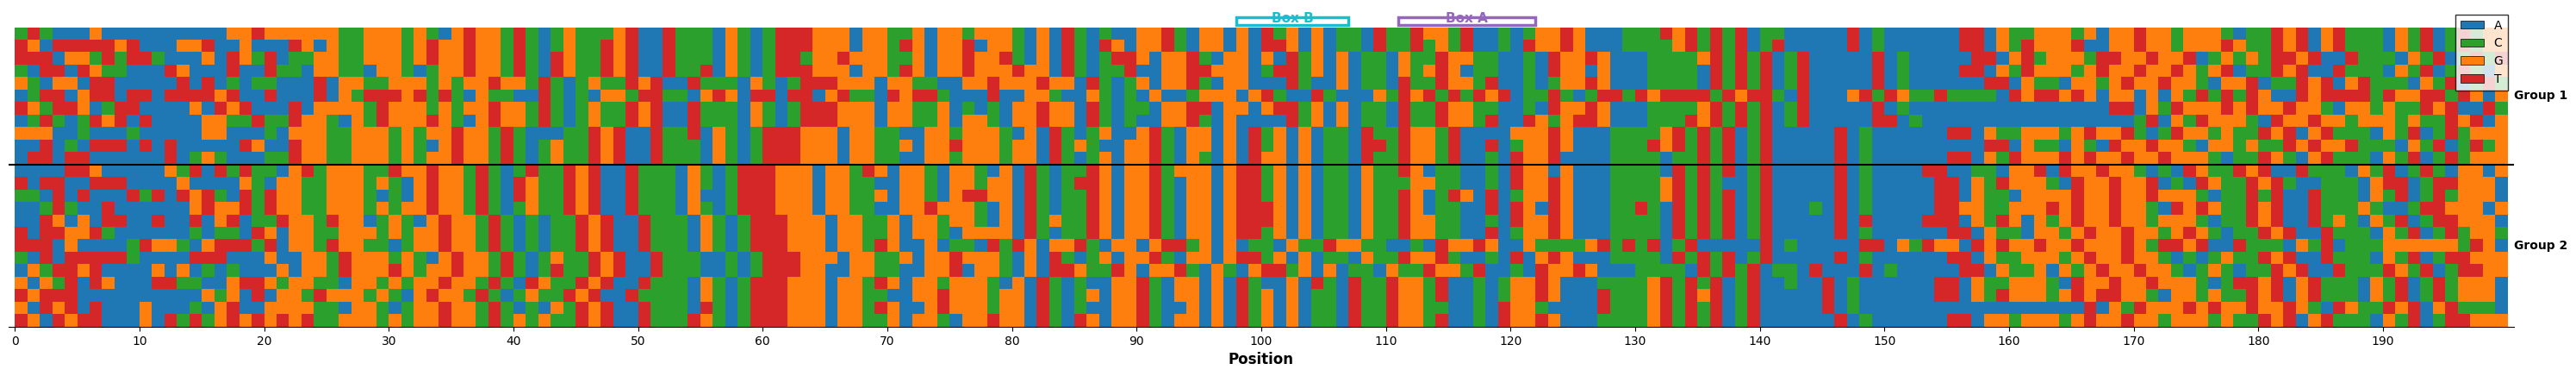

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle
from Bio import SeqIO
import matplotlib.patches as mpatches

def parse_fasta(fasta_file):
    """Parse FASTA file and return list of sequences"""
    sequences = []
    for record in SeqIO.parse(fasta_file, "fasta"):
        sequences.append(str(record.seq).upper())
    return sequences

# IUPAC nucleotide codes
IUPAC_CODES = {
    'A': ['A'],
    'C': ['C'],
    'G': ['G'],
    'T': ['T'],
    'R': ['A', 'G'],
    'Y': ['C', 'T'],
    'W': ['A', 'T'],
    'S': ['C', 'G'],
    'M': ['A', 'C'],
    'K': ['G', 'T'],
    'N': ['A', 'C', 'G', 'T']
}

def matches_iupac(base, iupac_code):
    """Check if a base matches an IUPAC code"""
    return base in IUPAC_CODES.get(iupac_code, [])

def find_iupac_motif_position(sequence, motif):
    """Find the position of IUPAC motif in sequence"""
    for i in range(len(sequence) - len(motif) + 1):
        match = True
        for j, motif_base in enumerate(motif):
            if not matches_iupac(sequence[i + j], motif_base):
                match = False
                break
        if match:
            return i, i + len(motif)
    return None, None

def find_motif_position(sequences, motif):
    """Find the position of IUPAC motif in sequences (return first match)"""
    for seq in sequences:
        start, end = find_iupac_motif_position(seq, motif)
        if start is not None:
            return start, end
    return None, None

def plot_nucleotide_heatmap(sequences, motif_A=None, motif_B=None, group_labels=None):
    """Plot clean nucleotide heatmap for publication"""
    
    if not sequences:
        return
    
    # Get dimensions
    n_seqs = len(sequences)
    max_len = max(len(seq) for seq in sequences)
    
    # Color mapping
    color_map = {
        'A': '#1f77b4',  
        'C': '#2ca02c', 
        'G': '#ff7f0e',  
        'T': '#d62728',
        'N': '#CCCCCC',
        '-': '#FFFFFF'
    }
    
    # Create figure
    fig, ax = plt.subplots(figsize=(max_len * 0.15, n_seqs * 0.15 + 1.5))
    
    # Plot each nucleotide as a colored square (no text)
    for seq_idx, seq in enumerate(sequences):
        for pos_idx, nuc in enumerate(seq):
            color = color_map.get(nuc, '#CCCCCC')
            rect = Rectangle((pos_idx, seq_idx), 1, 1, 
                           facecolor=color, edgecolor='none', linewidth=0)
            ax.add_patch(rect)
    
    # Find motif positions (use first occurrence as reference)
    if motif_A:
        start_A, end_A = find_motif_position(sequences, motif_A)
        if start_A is not None:
            # Draw box at the top
            rect = Rectangle((start_A, -0.8), end_A - start_A, 0.6, 
                           facecolor='none', edgecolor='#9467bd', 
                           linewidth=2.5, linestyle='-')
            ax.add_patch(rect)
            # Add label
            ax.text(start_A + (end_A - start_A)/2, -1.2, 'Box A', 
                   ha='center', va='top', fontsize=11, 
                   color='#9467bd', fontweight='bold')
    
    if motif_B:
        start_B, end_B = find_motif_position(sequences, motif_B)
        if start_B is not None:
            # Draw box at the top
            rect = Rectangle((start_B, -0.8), end_B - start_B, 0.6, 
                           facecolor='none', edgecolor='#17becf', 
                           linewidth=2.5, linestyle='-')
            ax.add_patch(rect)
            # Add label
            ax.text(start_B + (end_B - start_B)/2, -1.2, 'Box B', 
                   ha='center', va='top', fontsize=11, 
                   color='#17becf', fontweight='bold')
    
    # Add group separators and labels if provided
    if group_labels:
        current_pos = 0
        for label, count in group_labels:
            # Draw separator line
            if current_pos > 0:
                ax.axhline(current_pos, color='black', linewidth=1.5, linestyle='-')
            
            # Add group label on the right
            mid_pos = current_pos + count / 2
            ax.text(max_len + 0.5, mid_pos, label, 
                   ha='left', va='center', fontsize=10, 
                   fontweight='bold', rotation=0)
            
            current_pos += count
    
    # Set axis limits
    ax.set_xlim(-0.5, max_len + 0.5)
    ax.set_ylim(-1.5, n_seqs)
    
    # Remove y-axis labels and ticks
    ax.set_yticks([])
    ax.set_ylabel('')
    
    # X-axis
    ax.set_xlabel('Position', fontsize=12, fontweight='bold')
    ax.set_xticks(np.arange(0, max_len, 10))
    ax.set_xticklabels(np.arange(0, max_len, 10), fontsize=10)
    
    # Invert y-axis
    ax.invert_yaxis()
    
    # Remove spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    
    # Create clean legend
    legend_elements = [
        mpatches.Patch(facecolor='#1f77b4', edgecolor='black', linewidth=0.5, label='A'),
        mpatches.Patch(facecolor='#2ca02c', edgecolor='black', linewidth=0.5, label='C'),
        mpatches.Patch(facecolor='#ff7f0e', edgecolor='black', linewidth=0.5, label='G'),
        mpatches.Patch(facecolor='#d62728', edgecolor='black', linewidth=0.5, label='T')
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=10, 
             frameon=True, fancybox=False, edgecolor='black')
    
    ax.set_aspect('equal')
    
    return fig, ax

def main():
    # Input files
    fasta_file1 = '/scratch/st-cdeboer-1/sambina/position_mpra/outputs/7-repeat_elements/group1_0:11.fa'
    fasta_file2 = '/scratch/st-cdeboer-1/sambina/position_mpra/outputs/7-repeat_elements/group2_2630:2643.fa'
    
    # IUPAC Motifs to find
    motif_A = "TRGYNNARNNG"  # Box A (11 bases)
    motif_B = "GWTCRANNC"     # Box B (9 bases)
    
    print("Loading sequences...")
    
    # Parse FASTA files
    sequences1 = parse_fasta(fasta_file1)
    sequences2 = parse_fasta(fasta_file2)
    
    print(f"Group 1: {len(sequences1)} sequences")
    print(f"Group 2: {len(sequences2)} sequences")
    
    # Combine sequences
    all_sequences = sequences1 + sequences2
    
    # Check for motifs using IUPAC matching
    print(f"\nChecking IUPAC motif presence:")
    count_A = 0
    count_B = 0
    for seq in all_sequences:
        start_A, end_A = find_iupac_motif_position(seq, motif_A)
        if start_A is not None:
            count_A += 1
        start_B, end_B = find_iupac_motif_position(seq, motif_B)
        if start_B is not None:
            count_B += 1
    
    print(f"  Box A ({motif_A}): {count_A}/{len(all_sequences)} sequences")
    print(f"  Box B ({motif_B}): {count_B}/{len(all_sequences)} sequences")
    
    # Create group labels for the plot
    group_labels = [
        ('Group 1', len(sequences1)),
        ('Group 2', len(sequences2))
    ]
    
    # Plot combined heatmap
    fig, ax = plot_nucleotide_heatmap(all_sequences, 
                                      motif_A=motif_A, 
                                      motif_B=motif_B,
                                      group_labels=group_labels)
    
    plt.tight_layout()
    plt.savefig('nucleotide_heatmap_combined.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.savefig('nucleotide_heatmap_combined.pdf', bbox_inches='tight', facecolor='white')
    print("\nSaved plots:")
    print("  - nucleotide_heatmap_combined.png")
    print("  - nucleotide_heatmap_combined.pdf")
    plt.show()

if __name__ == "__main__":
    main()